In [ ]:
pip install matplotlib


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import matplotlib as plt          # as in Jupyter

In [ ]:
pip install opencv-python==4.6.0.66

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.0/30.0 MB 1.6 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.10.0.84
    Uninstalling opencv-python-4.10.0.84:
      Successfully uninstalled opencv-python-4.10.0.84

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
print(os.path.exists("cameraman.png"))


True


In [ ]:
pip install "numpy<2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 3.8 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.1
    Uninstalling numpy-2.1.1:
      Successfully uninstalled numpy-2.1.1

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


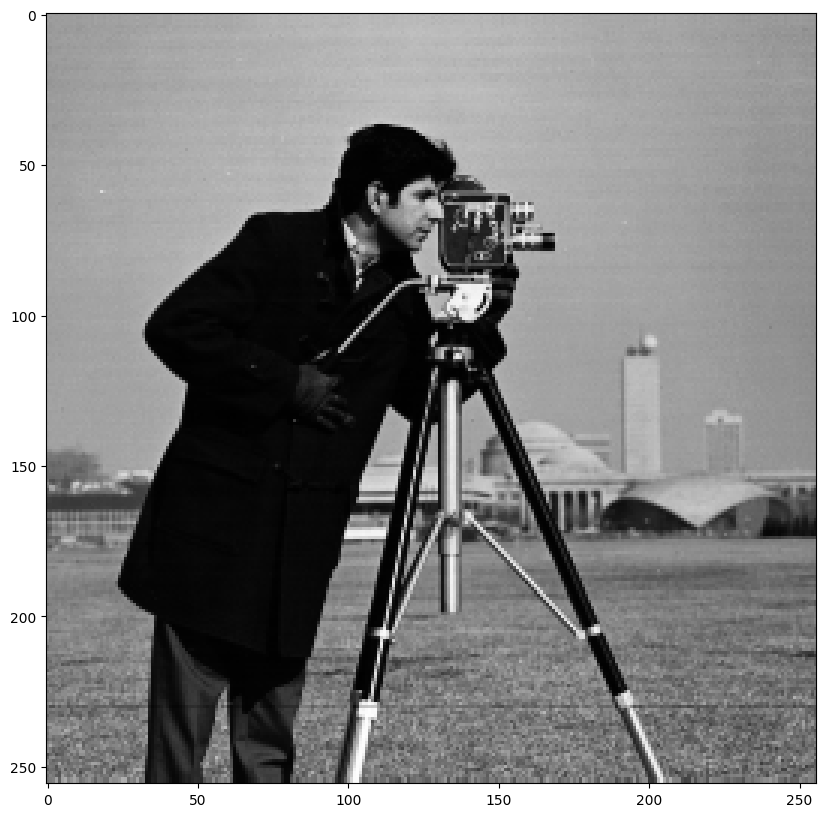

In [ ]:
# Import necessary libraries
import cv2  # OpenCV library for image processing
import numpy as np  # NumPy for numerical operations
import matplotlib.pyplot as plt  # Matplotlib for plotting
from pylab import rcParams  # rcParams for customizing plot size

# Set figure size for Matplotlib plots
rcParams['figure.figsize'] = 20, 10

# Load a test image using OpenCV (cv2)
# The image is read in color by default, so we need to convert it to a single channel (grayscale)
# The indexing [:,:,0] is used to select the first (and only) channel, effectively converting the image to grayscale
im = cv2.imread("cameraman.png")[:,:,0]

# Set the color map to grayscale using plt.gray()
plt.gray()

# Display the image using Matplotlib's imshow() function
plt.imshow(im)

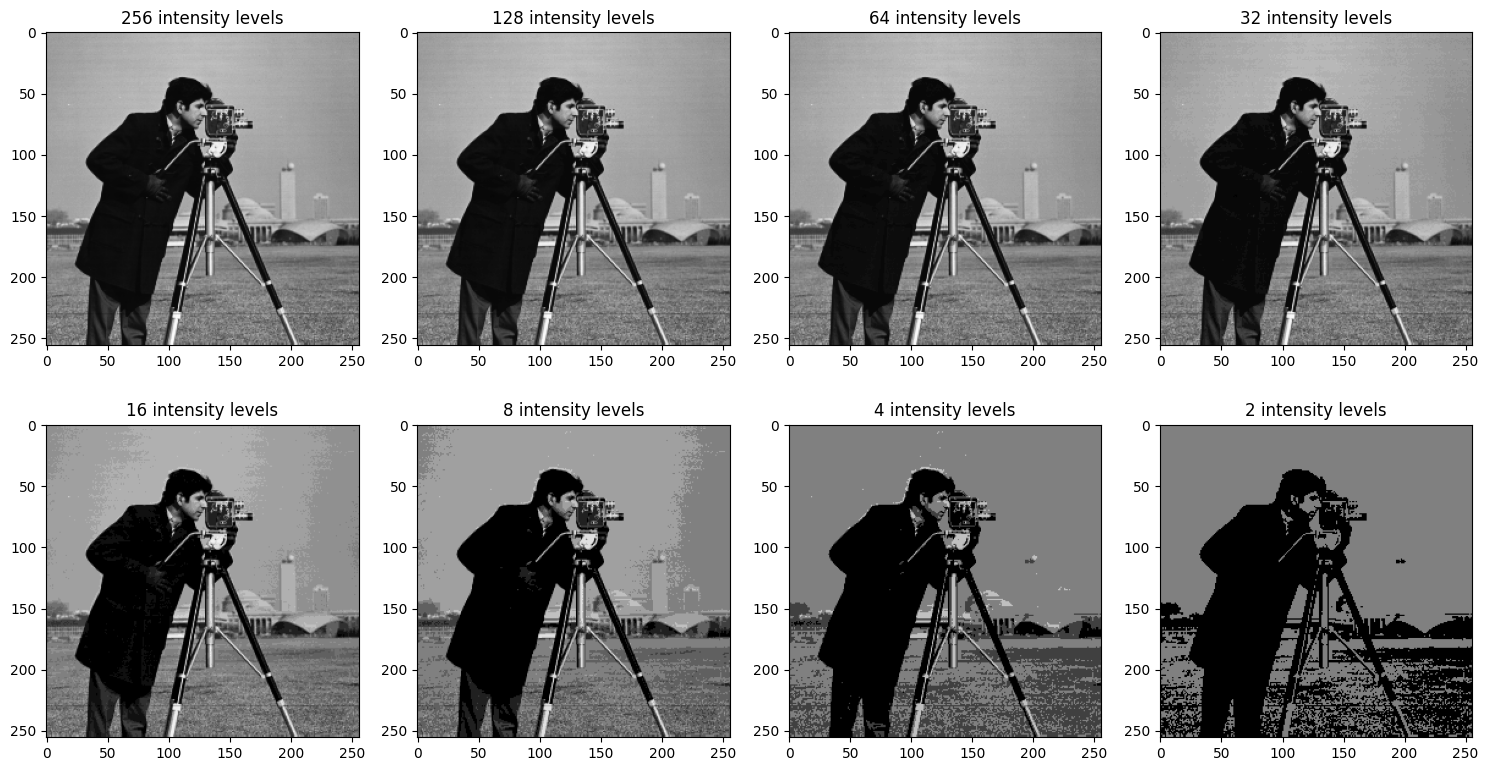

In [ ]:
from skimage import data
import numpy as np
import matplotlib.pyplot as plt

# Load the "cameraman" image
#im = data.camera()
im = cv2.imread("cameraman.png")[:,:,0]

# Create a figure with subplots
f, axarr = plt.subplots(2, 4, figsize=(15, 8))

# Initialize the number of intensity levels
levels = 256

# Loop through each row and column
for i in range(2):
    for j in range(4):
        # Quantize the intensity levels of the image
        im_mod = np.floor(im / (256 // levels)) * (256 // levels)
        im_mod = im_mod.astype(np.uint8)  # Ensure the type is uint8

        # Display the quantized image
        axarr[i, j].imshow(im_mod, cmap='gray', vmin=0, vmax=255)

        # Set the subplot title
        axarr[i, j].set_title(f'{levels} intensity levels')

        # Update the number of intensity levels
        levels //= 2  # Use integer division

# Adjust layout and display
plt.tight_layout()
plt.show()


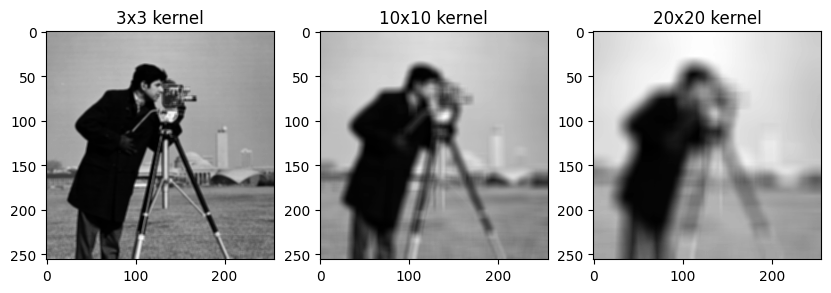

In [ ]:
#Using openCV to blur the image using a normalized block filter
f, axarr = plt.subplots(1, 3)
axarr[0].imshow(cv2.blur(im,(3,3)))
axarr[0].set_title('3x3 kernel')

axarr[1].imshow(cv2.blur(im,(10,10)))
axarr[1].set_title('10x10 kernel')

axarr[2].imshow(cv2.blur(im,(20,20)))
axarr[2].set_title('20x20 kernel');

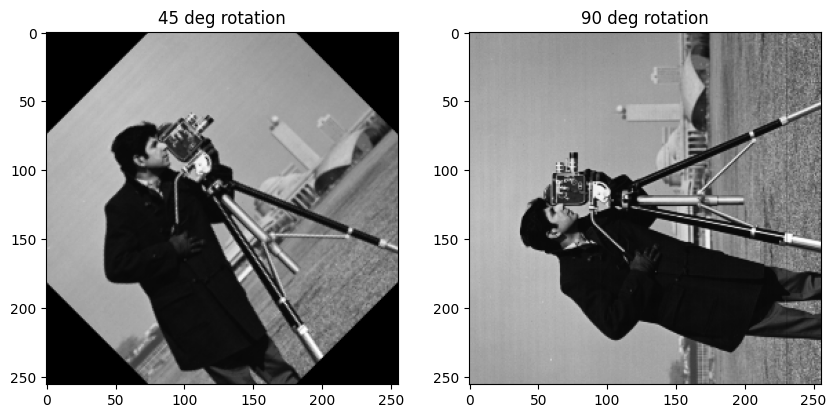

In [ ]:
rows,cols = im.shape
M = cv2.getRotationMatrix2D((cols/2,rows/2),45,1)
dst_45 = cv2.warpAffine(im,M,(cols,rows))

M = cv2.getRotationMatrix2D((cols/2,rows/2),90,1)
dst_90 = cv2.warpAffine(im,M,(cols,rows))

f, axarr = plt.subplots(1, 2)
axarr[0].imshow(dst_45)
axarr[0].set_title('45 deg rotation')

axarr[1].imshow(dst_90)
axarr[1].set_title('90 deg rotation');

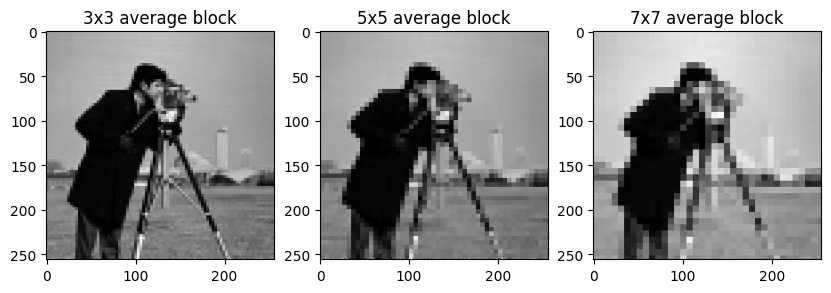

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

STRIDE = (3, 5, 7)
rows, cols = im.shape

f, axarr = plt.subplots(1, len(STRIDE))

for i, S in enumerate(STRIDE):
    im_mod = im.copy()
    for r in range(int(S/2), rows, S):
        for c in range(int(S/2), cols, S):
            im_mod[r-int(S/2):r+int(S/2)+1, c-int(S/2):c+int(S/2)+1] = np.average(im[r-int(S/2):r+int(S/2)+1, c-int(S/2):c+int(S/2)+1])
    axarr[i].imshow(im_mod)
    axarr[i].set_title('{}x{} average block'.format(S, S))

plt.show()


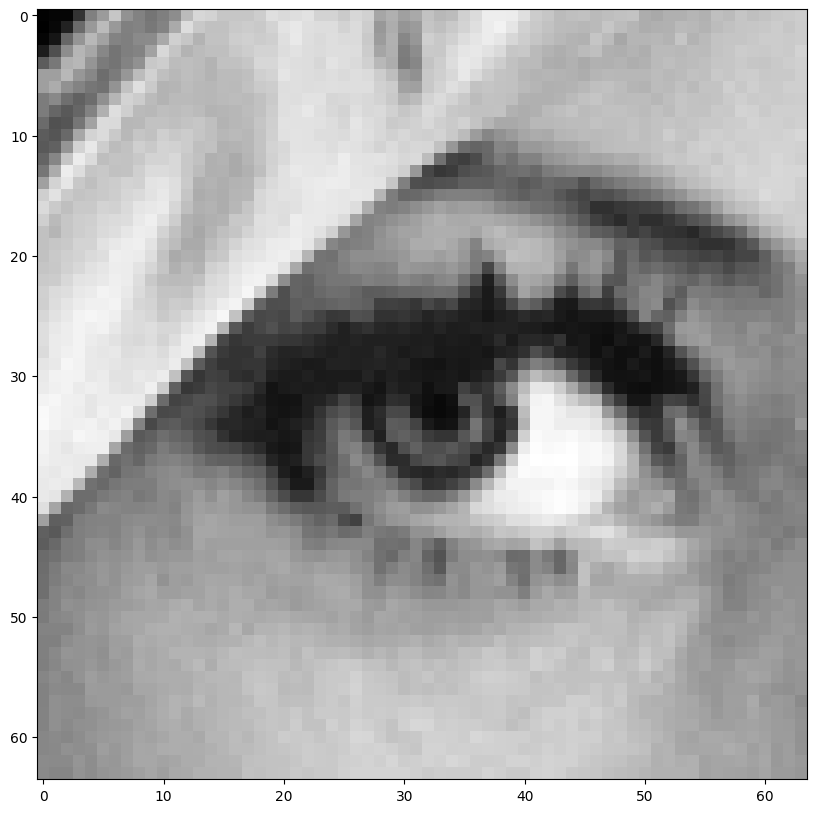

In [ ]:
%matplotlib inline

#import typical packages I'll be using
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pylab import rcParams
rcParams['figure.figsize'] = 10, 10  #boiler plate to set the size of the figures
plt.gray()  #start with gray scale image

im = cv2.imread("lena.tiff")
#convert for matplotlib from brg to Y CR CB for display
im = cv2.cvtColor(im, cv2.COLOR_BGR2YCR_CB)
#use only the Y channel
im = im[:,:,0]
#Only use part of the image to start
im = im[232:296,232:296]

plt.imshow(im)

In [ ]:
w,h = im.shape
block_size = 8

In [ ]:
blocks = np.zeros((block_size, block_size, w // block_size, h // block_size), dtype=np.int64)
for r in range(h // block_size):
    for c in range(w // block_size):
        blocks[r, c] = im[r*block_size : (r+1)*block_size, c*block_size : (c+1)*block_size]


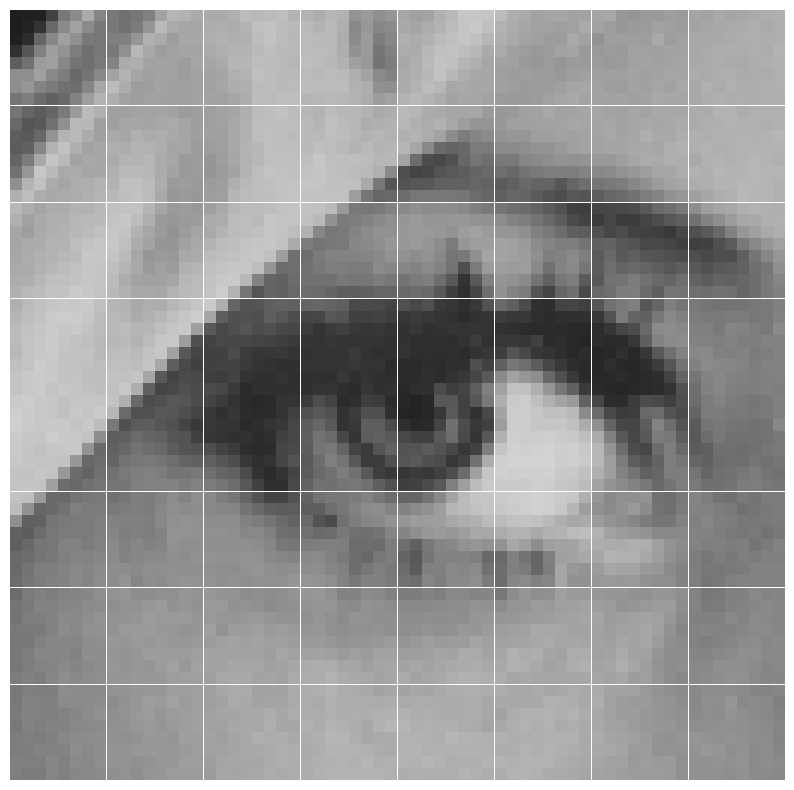

In [ ]:
f, axarr = plt.subplots(int(h/block_size), int(w/block_size))
f.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=.01, hspace=.01)

for r in range(int(h/block_size)):
    for c in range(int(w/block_size)):
        axarr[r, c].imshow(blocks[r, c], vmin=0, vmax=255)
        axarr[r, c].axis('equal')
        axarr[r, c].axis('off')
